In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import DDM

### Metas

In [4]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau", "decay"]
num_obs = 2000
num_configs = 6
num_regressors = 4
p_free = 0.5

### Priors

In [5]:
# Priors: intercept vs slope samplers per intrinsic
priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

### Context Manager

In [6]:
cm = ContextManager()  # not used in full-regression path

family = NestedModelFamily(
    name="DDM",
    model=DDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=intrinsic_params,
)

In [7]:
out = family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},  # different mask each run, reproducible
    )
)

In [8]:
out

{'model_name': 'DDM',
 'design_config': {'1': ['v', 'a', 'tau', 's_v'],
  'u_1': [],
  'u_2': [],
  'u_3': []},
 'design_matrix': array([[1.        , 0.9652515 , 1.        , 0.8797585 ],
        [1.        , 0.36230484, 1.        , 0.27924758],
        [1.        , 0.77393556, 1.        , 0.9421415 ],
        ...,
        [1.        , 0.9459616 , 1.        , 0.5227499 ],
        [1.        , 0.5016282 , 0.        , 0.02416566],
        [1.        , 0.3283829 , 0.        , 0.71007514]], dtype=float32),
 'param_mask': array([[1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]], dtype=float32),
 'param_matrix': array([[4.98383359e+00, 3.94574182e+00, 6.58898073e-01, 1.60386088e-03,
         2.39838300e-01, 8.14130766e-02],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       

In [9]:
design_matrix     = out["design_matrix"]
parameter_mask    = out["param_mask"]
parameter_matrix  = out["param_matrix"]
params_for_model  = out["param_samples"]
sim_data          = out["sim_trials"]

In [10]:
design_matrix

array([[1.        , 0.9652515 , 1.        , 0.8797585 ],
       [1.        , 0.36230484, 1.        , 0.27924758],
       [1.        , 0.77393556, 1.        , 0.9421415 ],
       ...,
       [1.        , 0.9459616 , 1.        , 0.5227499 ],
       [1.        , 0.5016282 , 0.        , 0.02416566],
       [1.        , 0.3283829 , 0.        , 0.71007514]], dtype=float32)

In [11]:
parameter_mask

array([[1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]], dtype=float32)

In [12]:
parameter_matrix

array([[4.98383359e+00, 3.94574182e+00, 6.58898073e-01, 1.60386088e-03,
        2.39838300e-01, 8.14130766e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]])

In [13]:
sim_data

{'rts': array([0.6818766 , 1.0872567 , 0.62815744, ..., 0.646464  , 0.76474863,
        1.1136364 ], dtype=float32),
 'choices': array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)}

In [14]:
print("design_matrix shape        :", design_matrix.shape)        # (N, K)
print("parameter_mask shape       :", parameter_mask.shape)       # (K, M)
print("parameter_matrix shape     :", parameter_matrix.shape)     # (K, M)

design_matrix shape        : (2000, 4)
parameter_mask shape       : (4, 6)
parameter_matrix shape     : (4, 6)


In [15]:
design_matrix

array([[1.        , 0.9652515 , 1.        , 0.8797585 ],
       [1.        , 0.36230484, 1.        , 0.27924758],
       [1.        , 0.77393556, 1.        , 0.9421415 ],
       ...,
       [1.        , 0.9459616 , 1.        , 0.5227499 ],
       [1.        , 0.5016282 , 0.        , 0.02416566],
       [1.        , 0.3283829 , 0.        , 0.71007514]], dtype=float32)

In [16]:
intrinsic_values_matrix = (design_matrix @ parameter_matrix).astype(np.float32)
assert intrinsic_values_matrix.shape == (num_obs, len(intrinsic_params))

In [17]:
col_idx = {name: j for j, name in enumerate(intrinsic_params)}
v_arr = params_for_model["v"]
a_arr = params_for_model["a"]
print(col_idx, v_arr, a_arr)

{'v': 0, 'a': 1, 'tau': 2, 's_v': 3, 's_tau': 4, 'decay': 5} [4.2975106 4.2975106 4.2975106 ... 4.2975106 4.2975106 4.2975106] [3.2717469 3.2717469 3.2717469 ... 3.2717469 3.2717469 3.2717469]


In [18]:
intercepts = out["param_samples"].get("_intercepts", {})
print("Intercepts:", {k: round(v, 4) for k, v in intercepts.items()})

Intercepts: {}


In [19]:
rts = sim_data["rts"]
choices = sim_data["choices"]
print("Simulated RTs:", np.nanmin(rts[rts>0]), "→", np.nanmax(rts))
print("Choice rate (mean):", np.mean(choices))

Simulated RTs: 0.46229774 → 1.6859235
Choice rate (mean): 1.0


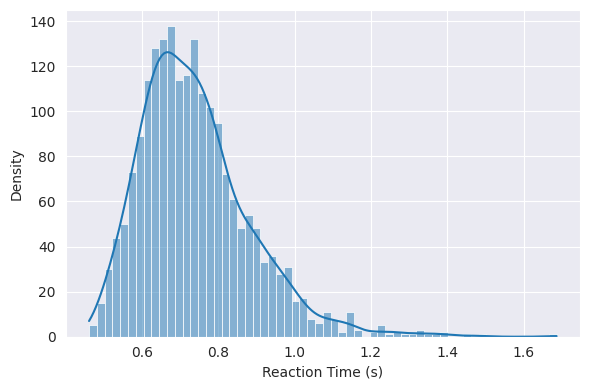

In [20]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(rts[rts > 0], bins=60, kde=True, ax=ax)
ax.set_xlabel("Reaction Time (s)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### Testing multiple batches

In [21]:
runs = []
for k in range(num_configs):
    res = family.sample(
        design_config=None,                 # AUTO: build_random_parameter_mask + mask_to_design_config
        num_obs=num_obs,
        num_regressors=num_regressors,
        mask_randomizer_kwargs=dict(
            mandatory_intrinsics={"v", "a"},
            intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},
        ),
    )
    runs.append(res)

In [22]:
def check_run(res):
    dm, pm = res["design_matrix"], res["param_matrix"]
    assert dm.shape == (num_obs, num_regressors)
    rts = res["sim_trials"]["rts"]; choices = res["sim_trials"]["choices"]
    assert rts.shape == (num_obs,) and choices.shape == (num_obs,)
    assert np.isfinite(rts).all()  # if timeouts exist they’ll be -1.0; adjust if you want to allow them
    return rts

all_rts = [check_run(r) for r in runs]
print(f"OK: ran {len(runs)} configs × {num_obs} trials with AUTO full-regression.")

OK: ran 6 configs × 2000 trials with AUTO full-regression.


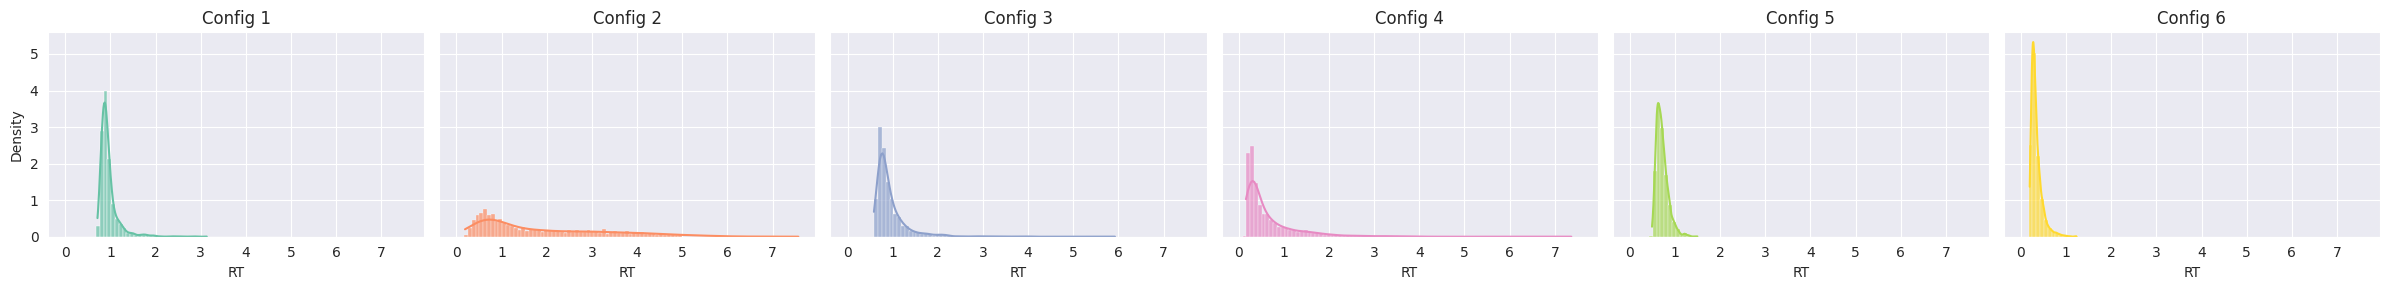

In [23]:
fig, axes = plt.subplots(1, num_configs, figsize=(4*num_configs, 3), sharex=True, sharey=True)
bins = np.linspace(0.0, 5.0, 60)
palette = sns.color_palette("Set2", n_colors=num_configs)

for ax, rts, idx in zip(np.atleast_1d(axes), all_rts, range(num_configs)):
    sns.histplot(rts, bins=bins, stat="density", kde=True, color=palette[idx], alpha=0.7, ax=ax)
    ax.set_title(f"Config {idx+1}")
    ax.set_xlabel("RT")
    ax.set_ylabel("Density")

plt.tight_layout()

### Batch sampling

In [59]:
samples = family.batch_sample(
    batch_size=2,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},
    ),
    min_num_obs=1000,
    max_num_obs=5000
)

[1798. 1798.] [1. 1.]


In [60]:
samples

{'design_matrices': array([[[1.],
         [1.],
         [1.],
         ...,
         [1.],
         [1.],
         [1.]],
 
        [[1.],
         [1.],
         [1.],
         ...,
         [1.],
         [1.],
         [1.]]], dtype=float32),
 'param_mask': array([[[1., 1., 1., 1., 1., 1.]],
 
        [[1., 1., 1., 1., 1., 1.]]], dtype=float32),
 'param_matrices': array([[[1.264946  , 3.6254377 , 1.0496843 , 0.14213958, 0.32245862,
          0.0867172 ]],
 
        [[2.215023  , 2.663371  , 0.5673528 , 0.00423419, 0.02087715,
          0.32037452]]], dtype=float32),
 'param_samples': {'v': array([[0.82041866, 0.82041866, 0.82041866, ..., 0.82041866, 0.82041866,
          0.82041866],
         [1.6254708 , 1.6254708 , 1.6254708 , ..., 1.6254708 , 1.6254708 ,
          1.6254708 ]], dtype=float32),
  'a': array([[2.9585793, 2.9585793, 2.9585793, ..., 2.9585793, 2.9585793,
          2.9585793],
         [2.037614 , 2.037614 , 2.037614 , ..., 2.037614 , 2.037614 ,
          2.037614 ]

In [43]:
samples['sim_data']['rts'][1].shape

(4850,)